## initial mapping workflow for supratidal forests (STF)
- works on geojson GA coastal tiles `../data/geojson/ga_summary_grid_c3_coastal.geojson`
- select `time_range` and if to `export` results as tif

In [1]:
%matplotlib inline

import sys
from osgeo import gdal
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

from shapely.geometry import Point

sys.path.insert(1, "/home/jovyan/code/dea-notebooks/Tools")
import datacube
from dea_tools.plotting import display_map
from datacube.utils.cog import write_cog
from datacube.utils.geometry import Geometry
from dea_tools.spatial import xr_rasterize
dc = datacube.Datacube()

# load virtual product
import importlib
from datacube.virtual import catalog_from_file
from datacube.virtual import DEFAULT_RESOLVER
catalog = catalog_from_file('../virtual_products/virtual_product_cat_wcf.yaml')

# Load HAT gpkg
#Hat_file = '../data/HAT_MLP_Regression.gpkg'
Hat_file = gpd.read_file('../data/HAT_MLP_Regression.gpkg')

# Load Storm Surge Elev Classes geojson
SS = gpd.read_file('../data/STF_SS_ElevationClasses.geojson')

## user inputs: tile, time and export geotiffs?

In [2]:
# add time (not a range, just repeat year input here)
time_range = ("2020", "2020")

# export as geotiff?
export = True

### using GA coastal tiles geojson

In [3]:
# GA coastal tiles
vector_file = '../data/geojson/ga_summary_grid_c3_coastal_Raf2.geojson'
attribute_col = 'geometry'

gdf = gpd.read_file(vector_file)
mainland_grid = gdf[gdf['type'] == 'mainland']

id_list = []
for index, row in mainland_grid.iterrows():
    id_list.append(row['id'])


In [4]:
#Converting HAT file to CRS 4326 to match mainland_grid
Hat_file = Hat_file.set_geometry("geometry")
Hat_conv = Hat_file.to_crs("EPSG:4326")

In [5]:
#Using sjoin to add max HAT value to mainland_grid
joined_mainland_grid = gpd.sjoin(Hat_conv, mainland_grid, op='within')
max_values_polygon = joined_mainland_grid.groupby('index_right')['HAT'].max()
mainland_grid['HAT_max'] = max_values_polygon.astype(float)

/env/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3488: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):
/env/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [6]:
#checking NaN values and replacing them with values from adjacent tiles ---NaN values in ID 52 (51) and 235 (234) will be replaced by nearby ID 53 (4.213) and ID 243 (1.904), respectively

#pd.set_option('display.max_rows', None)
#mainland_grid


mainland_grid.loc[51,'HAT_max'] = '4.213'
mainland_grid.loc[234,'HAT_max'] = '1.904'

In [7]:
#to convert object to float
mainland_grid['HAT_max'] = mainland_grid['HAT_max'].astype('float32')

<Axes: >

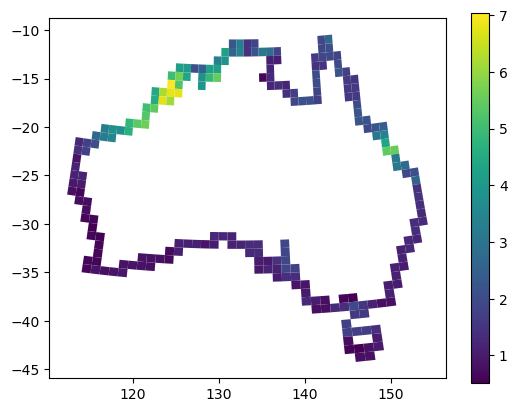

In [8]:
mainland_grid.plot(column = 'HAT_max', legend=True)

In [52]:

SS.iloc[[3]].geometry.values

<GeometryArray>
[<MULTIPOLYGON (((112 -16.5, 112 -8.054, 154.498 -8.053, 154.498 -16.499, 112...>]
Length: 1, dtype: geometry

<Axes: >

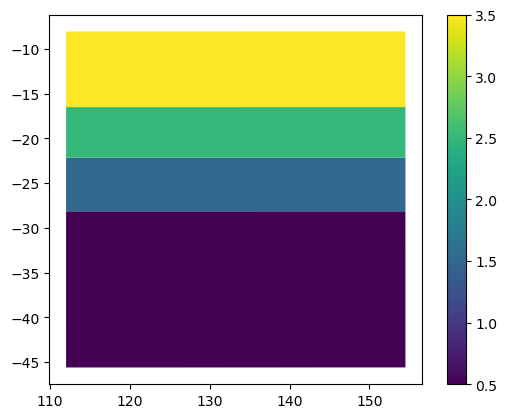

In [13]:
SS.plot(column = 'SSElev', legend=True)

In [10]:
intersection_gdf = gpd.overlay(mainland_grid, SS, how='intersection')
mainland_grid['SSurge'] = intersection_gdf['SSElev']

/env/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [21]:
mainland_grid

,region_code,ix,iy,utc_offset,id,type,geometry,HAT_max,SSurge
11,x27y44,27,44,9,12,mainland,"POLYGON ((131.14236 -10.95979, 131.13657 -11.8...",2.281984,3.5
12,x28y44,28,44,9,13,mainland,"POLYGON ((132.00000 -10.96278, 132.00000 -11.8...",3.264788,3.5
13,x29y44,29,44,9,14,mainland,"POLYGON ((132.85764 -10.95979, 132.86343 -11.8...",1.480018,3.5
14,x30y44,30,44,9,15,mainland,"POLYGON ((133.71520 -10.95084, 133.72679 -11.8...",1.851971,3.5
18,x39y44,39,44,9,19,mainland,"POLYGON ((141.41707 -10.60201, 141.48049 -11.4...",1.936941,3.5
...,...,...,...,...,...,...,...,...,...
317,x40y07,40,7,10,318,mainland,"POLYGON ((145.64093 -42.46921, 145.76292 -43.3...",0.563889,NaN
318,x41y07,41,7,10,319,mainland,"POLYGON ((146.76796 -42.37058, 146.89986 -43.2...",0.809309,NaN
319,x42y07,42,7,10,320,mainland,"POLYGON ((147.89269 -42.26423, 148.03442 -43.1...",0.974766,NaN
320,x40y06,40,6,10,321,mainland,"POLYGON ((145.76292 -43.35558, 145.88711 -44.2...",0.758778,NaN


<Axes: >

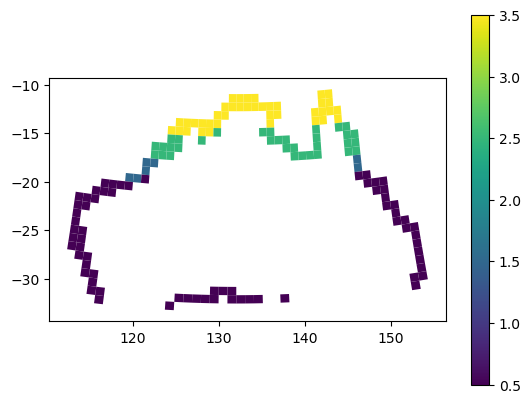

In [22]:
#Not sure what's wrong here... why other rows are not populated
mainland_grid.plot(column = 'SSurge', legend=True)

In [23]:
#Let's replace all NaN values for 0.5
mainland_grid['SSurge'].fillna(0.5, inplace=True)

/tmp/ipykernel_686/1927798214.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mainland_grid['SSurge'].fillna(0.5, inplace=True)


<Axes: >

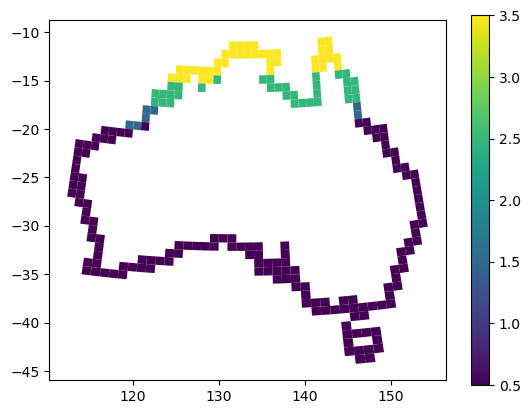

In [24]:
mainland_grid.plot(column = 'SSurge', legend=True)

In [25]:
mainland_grid

,region_code,ix,iy,utc_offset,id,type,geometry,HAT_max,SSurge
11,x27y44,27,44,9,12,mainland,"POLYGON ((131.14236 -10.95979, 131.13657 -11.8...",2.281984,3.5
12,x28y44,28,44,9,13,mainland,"POLYGON ((132.00000 -10.96278, 132.00000 -11.8...",3.264788,3.5
13,x29y44,29,44,9,14,mainland,"POLYGON ((132.85764 -10.95979, 132.86343 -11.8...",1.480018,3.5
14,x30y44,30,44,9,15,mainland,"POLYGON ((133.71520 -10.95084, 133.72679 -11.8...",1.851971,3.5
18,x39y44,39,44,9,19,mainland,"POLYGON ((141.41707 -10.60201, 141.48049 -11.4...",1.936941,3.5
...,...,...,...,...,...,...,...,...,...
317,x40y07,40,7,10,318,mainland,"POLYGON ((145.64093 -42.46921, 145.76292 -43.3...",0.563889,0.5
318,x41y07,41,7,10,319,mainland,"POLYGON ((146.76796 -42.37058, 146.89986 -43.2...",0.809309,0.5
319,x42y07,42,7,10,320,mainland,"POLYGON ((147.89269 -42.26423, 148.03442 -43.1...",0.974766,0.5
320,x40y06,40,6,10,321,mainland,"POLYGON ((145.76292 -43.35558, 145.88711 -44.2...",0.758778,0.5


In [26]:
#creating a new column in mainland_grid and populating with the sum of HAT and Storm Surge
mainland_grid['HATSS'] = mainland_grid['HAT_max'] + mainland_grid['SSurge']

/env/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [27]:
mainland_grid

,region_code,ix,iy,utc_offset,id,type,geometry,HAT_max,SSurge,HATSS
11,x27y44,27,44,9,12,mainland,"POLYGON ((131.14236 -10.95979, 131.13657 -11.8...",2.281984,3.5,5.781984
12,x28y44,28,44,9,13,mainland,"POLYGON ((132.00000 -10.96278, 132.00000 -11.8...",3.264788,3.5,6.764788
13,x29y44,29,44,9,14,mainland,"POLYGON ((132.85764 -10.95979, 132.86343 -11.8...",1.480018,3.5,4.980018
14,x30y44,30,44,9,15,mainland,"POLYGON ((133.71520 -10.95084, 133.72679 -11.8...",1.851971,3.5,5.351971
18,x39y44,39,44,9,19,mainland,"POLYGON ((141.41707 -10.60201, 141.48049 -11.4...",1.936941,3.5,5.436941
...,...,...,...,...,...,...,...,...,...,...
317,x40y07,40,7,10,318,mainland,"POLYGON ((145.64093 -42.46921, 145.76292 -43.3...",0.563889,0.5,1.063889
318,x41y07,41,7,10,319,mainland,"POLYGON ((146.76796 -42.37058, 146.89986 -43.2...",0.809309,0.5,1.309309
319,x42y07,42,7,10,320,mainland,"POLYGON ((147.89269 -42.26423, 148.03442 -43.1...",0.974766,0.5,1.474766
320,x40y06,40,6,10,321,mainland,"POLYGON ((145.76292 -43.35558, 145.88711 -44.2...",0.758778,0.5,1.258778


<Axes: >

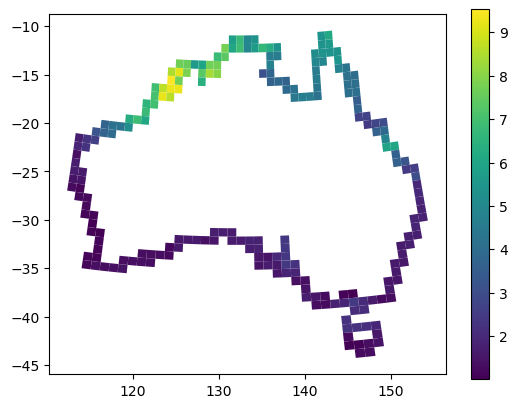

In [29]:
mainland_grid.plot(column = 'HATSS', legend=True)

In [30]:
#Visualising the mainland_grid
mainland_grid.explore()

### select the tile of interest (click on map above and find value for `id` and manually select using `loc` below)

In [72]:
gdf = mainland_grid.loc[mainland_grid['id'] == 280]

In [73]:
gdf.explore()

In [74]:
# Create the 'query' dictionary object
res = (-30, 30)

query = {
    "time": time_range,
    'resolution':res}

In [75]:
# Loop through polygons in geodataframe and add geom to queries
for index, row in gdf.iterrows():
    print(f'Feature: {index + 1}/{len(gdf)}')
    
    # Extract the feature's geometry as a datacube geometry object
    geom = Geometry(geom=row.geometry, crs=gdf.crs)
    
    # Update the query to include our geopolygon
    query.update({'geopolygon': geom})

# Extracting specific keys from dictionary (removing time to load things like item and srtm)
query_notime = {key: query[key] for key in query.keys()
       & {'resolution', 'geopolygon'}}

Feature: 280/1


### load SRTM, item, mangroves

In [76]:
# Load STRM
srtm_ds = dc.load(product = 'ga_srtm_dem1sv1_0', output_crs="EPSG:3577", **query_notime)
srtm = srtm_ds.dem_h

# Load item
item_ds = dc.load(product = 'item_v2', output_crs="EPSG:3577", **query_notime)
item = item_ds.relative

# Load in mangrove cover
DEAmangrove = dc.load(product = 'ga_ls_mangrove_cover_cyear_3', output_crs="EPSG:3577", **query)

# if no mangroves within AOI, create dummy xr.dataarray
if DEAmangrove.data_vars == {}:
    mangrove = xr.DataArray(np.zeros_like(srtm), coords=srtm.coords, dims=srtm.dims, attrs=srtm.attrs)
else:
    # get output of mangrove == 1, not mangrove == 0
    mangrove = (DEAmangrove.canopy_cover_class != 255)

### load in woody cover virtual product

In [77]:
# load in vp woody cover
sys.path.insert(1, '../virtual_products') 
# The dictionary which datacube uses to understand (resolve) the different virtual product functionality
# Need to add any aggregations for the VP you're using

# Get location of transformation
aggregation = "best_pixel_gmad"
agg_loc = importlib.import_module(aggregation)
agg_class = aggregation.split('.')[-1]

DEFAULT_RESOLVER.register('aggregate', agg_class, getattr(agg_loc, agg_class) )

VirtualProductException: name best_pixel_gmad under aggregate is already registered

In [78]:
# Need to add any tranformations for the VP you're using

# Get location of transformation
transformation = "woody_cover"
trans_loc = importlib.import_module(transformation)
trans_class = transformation.split('.')[-1]

DEFAULT_RESOLVER.register('transform', trans_class, getattr(trans_loc, trans_class) )

VirtualProductException: name woody_cover under transform is already registered

In [79]:
# load woody_cover vp
product = catalog['woody_cover']
woody_cover_vp = product.load(dc, **query)

# # woody cover with threshold for saltmarsh
woody_cover = xr.where(woody_cover_vp.woody_cover > 0.5, 1, 0).astype('int8')
woody_cover.attrs['crs'] = 'EPSG:3577'

/env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### create initial supratidal forest extent product

In [80]:
## wrangle binary maps and create STF mask

# not mangrove == True
not_mangrove = (1 - mangrove)
not_mangrove = not_mangrove == 1


#SRTM --- 3 thresholds HAT, HATSS, 10m

#HAT
#You need to grab the value from the list using np.unique(gdf['HAT_max'])[0]
HATmax = np.unique(gdf['HAT_max'])[0]
lessthan_HATmax = srtm <= HATmax
HAT_threshold_srtm = lessthan_HATmax

#HATSS
HATSS_max = np.unique(gdf['HATSS'])[0]
lessthan_HATSSmax = srtm <= HATSS_max
HATSS_threshold_srtm = lessthan_HATSSmax 

#10m
AHD_max = 10
lessthan10m_AHD = srtm <= AHD_max
AHD_threshold_srtm = lessthan10m_AHD

# item (remove all intertidal areas)
not_intertidal = item == 9

# remove time dim
not_mangrove = not_mangrove.squeeze('time')
AHD_threshold_srtm = AHD_threshold_srtm.squeeze('time')
not_intertidal = not_intertidal.squeeze('time')

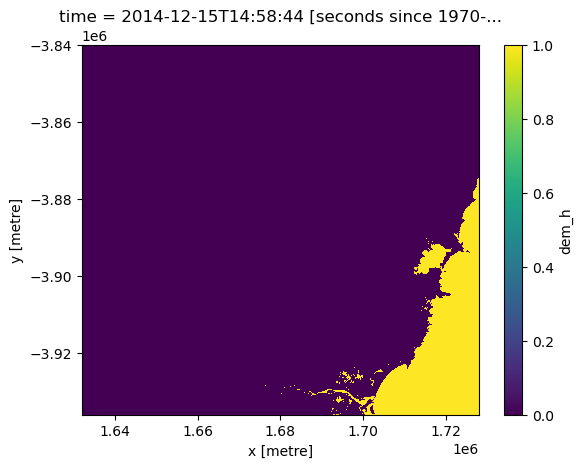

In [81]:
HAT_threshold_srtm.plot()

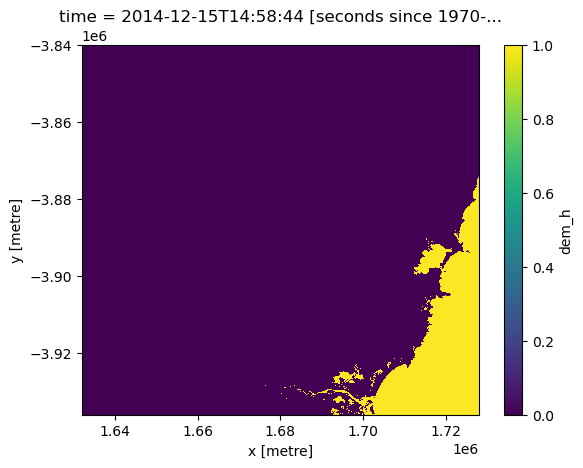

In [82]:
HATSS_threshold_srtm.plot()

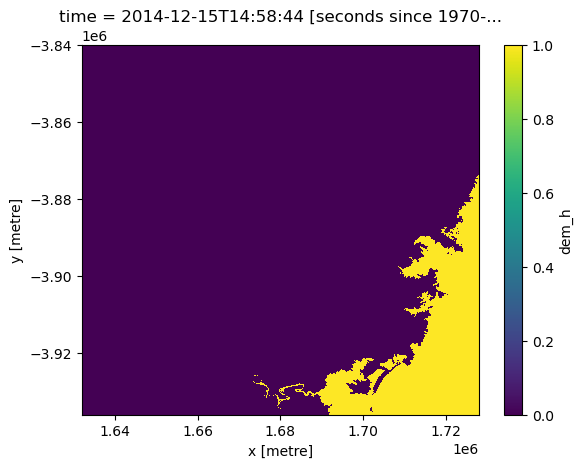

In [83]:
AHD_threshold_srtm.plot()

In [84]:
# combine masks and exploring three different STF
STF_HAT = xr.where((not_mangrove == False) + (HAT_threshold_srtm == False) + (not_intertidal == False) + (woody_cover == False), 0, 1).astype('int8')
STF_HATSS = xr.where((not_mangrove == False) + (HATSS_threshold_srtm == False) + (not_intertidal == False) + (woody_cover == False), 0, 1).astype('int8')
STF_AHD = xr.where((not_mangrove == False) + (AHD_threshold_srtm == False) + (not_intertidal == False) + (woody_cover == False), 0, 1).astype('int8')

In [85]:
# Generate a polygon mask to keep only data within the polygon
mask = xr_rasterize(gdf, srtm_ds)

# Mask dataset to set pixels outside the polygon to `NaN`
STF_HAT = STF_HAT.where(mask)
STF_HATSS = STF_HATSS.where(mask)
STF_AHD = STF_AHD.where(mask)

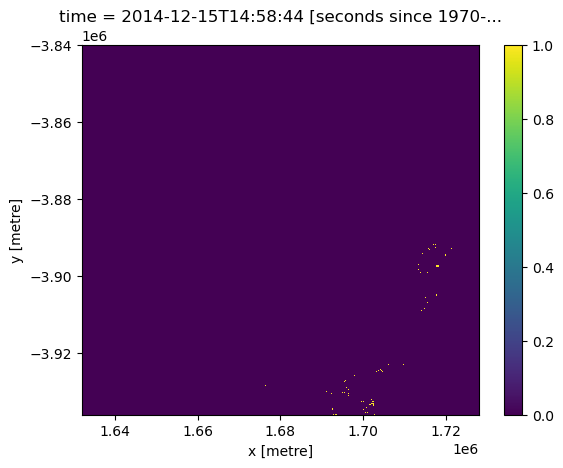

In [86]:
STF_HAT.plot()
#STF_HATSS.plot()
#STF_AHD.plot()

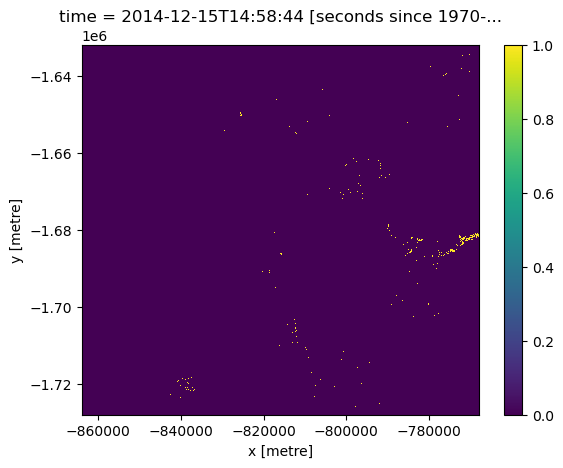

In [66]:
STF_HATSS.plot()
#STF_AHD.plot()

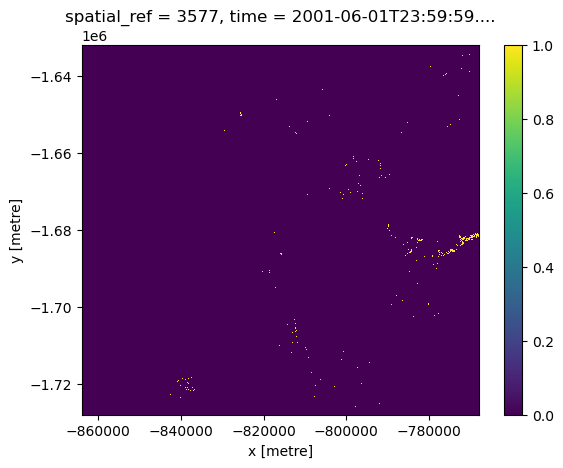

In [67]:
STF_AHD.plot()

### combine inputs and output to 9 band xarray dataset
- band 1: mangrove (1), no mangrove (0)
- band 2: SRTM data (raw elevation values)
- band 3: SRTM threshold between 1-10 (1), outside this range (0)
- band 4: ITEMs intertidal areas (1), non intertidal areas (0)
- band 5: woody cover fraction data (raw fraction values 0-1)
- band 6: woody cover fraction threshold >0.5 (1), <0.5 (0)
- band 7: STF_HAT present (1), STF absent (0)
- band 8: STF_HATSS present (1), STF absent (0)
- band 8: STF_AHD present (1), STF absent (0)

In [69]:
# make all into datasets and merge
variables_xarray_list = []

# band 1
mangrove_ds = mangrove.to_dataset(name="mangrove").squeeze().drop('time')
variables_xarray_list.append(mangrove_ds)

# band 2
srtm_false_value_remove = xr.where(srtm < -10 ,0, srtm.values)
srtm_ds = srtm_false_value_remove.to_dataset(name="SRTM").squeeze().drop('time')
variables_xarray_list.append(srtm_ds)

# band 3
AHD_threshold_srtm_ds = AHD_threshold_srtm.to_dataset(name="SRTM_threshold").squeeze().drop('time')
variables_xarray_list.append(AHD_threshold_srtm_ds)

# band 4
intertidal = xr.where(not_intertidal == True, 0, 1).astype('int8')
intertidal_ds = intertidal.to_dataset(name="intertidal_and_below").squeeze().drop('time')
variables_xarray_list.append(intertidal_ds)

# band 5
woody_cover_raw = woody_cover_vp.woody_cover
woody_cover_raw_mask_intertidal = woody_cover_raw.where(not_intertidal) # mask by intertidal due to WCF values in water that are erronous (note this means areas in the intertidal are not masked for WCF, which we actually may want to know about for STF vs saltmarsh)
woody_cover_raw_mask_intertidal_ds = woody_cover_raw_mask_intertidal.to_dataset(name="woody_cover").squeeze()
variables_xarray_list.append(woody_cover_raw_mask_intertidal_ds)

# band 6
woody_cover_threshold_ds = woody_cover.to_dataset(name="woody_cover_threshold").squeeze()
variables_xarray_list.append(woody_cover_threshold_ds)

# band 7
STF_HAT_ds = STF_HAT.to_dataset(name="STF_HAT")#.squeeze().drop('time')
variables_xarray_list.append(STF_HAT_ds)


# band 8
STF_HATSS_ds = STF_HATSS.to_dataset(name="STF_HATSS")#.squeeze().drop('time')
variables_xarray_list.append(STF_HATSS_ds)

# band 9
STF_AHD_ds = STF_AHD.to_dataset(name="STF_AHD")#.squeeze().drop('time')
variables_xarray_list.append(STF_AHD_ds)

stacked_xarray = xr.merge(variables_xarray_list)

### output to geotiff

In [70]:
def set_band_names(input_img: str, band_names: list, feedback: bool = False):
    """
    NOTE: Function is from RSGISlib that is not avaliable on DEA sandbox
    A utility function to set band names.

    :param input_img: input image file.
    :param band_names: is a list of band names
    :param feedback: is a boolean specifying whether feedback will be printed to the
                     console (True= Printed / False (default) Not Printed)

    .. code:: python

        from rsgislib import imageutils

        input_img = 'injune_p142_casi_sub_utm.kea'
        band_names = ['446nm','530nm','549nm','569nm','598nm','633nm','680nm','696nm',
                      '714nm','732nm','741nm','752nm','800nm','838nm']

        imageutils.set_band_names(input_img, band_names)

    """
    dataset = gdal.Open(input_img, gdal.GA_Update)

    for i in range(len(band_names)):
        band = i + 1
        bandName = band_names[i]

        imgBand = dataset.GetRasterBand(band)
        # Check the image band is available
        if not imgBand is None:
            if feedback:
                print('Setting Band {0} to "{1}"'.format(band, bandName))
            imgBand.SetDescription(bandName)
        else:
            raise rsgislib.RSGISPyException("Could not open the image band: ", band)


In [91]:
stacked_xarray

<xarray.Dataset>
Dimensions:                (y: 3201, x: 3201)
Coordinates:
  * y                      (y) float64 -1.728e+06 -1.728e+06 ... -1.632e+06
  * x                      (x) float64 -8.64e+05 -8.64e+05 ... -7.68e+05
    spatial_ref            int32 3577
    time                   datetime64[ns] 2014-12-15T14:58:44
Data variables:
    mangrove               (y, x) bool False False False ... False False False
    SRTM                   (y, x) float32 0.0 0.0 0.0 0.0 ... 61.45 62.59 64.08
    SRTM_threshold         (y, x) bool True True True True ... False False False
    intertidal_and_below   (y, x) int8 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0
    woody_cover            (y, x) float64 nan nan nan nan ... nan nan nan nan
    woody_cover_threshold  (y, x) float32 nan 0.0 0.0 0.0 ... nan nan nan nan
    STF_HAT                (y, x) float32 nan 0.0 0.0 0.0 ... nan nan nan nan
    STF_HATSS              (y, x) float32 nan 0.0 0.0 0.0 ... nan nan nan nan
    STF_AHD                (y, x) float32 nan 0.0 0.0 0.0 ... nan nan nan nan

In [89]:
stacked_xarray = stacked_xarray.squeeze('time')

In [90]:
if export == False:
    pass
else:
    write_cog(geo_im=stacked_xarray.to_array(),
              fname='initial_STF_model_coastal_tile_gridID_' + gdf['id'].astype(str).item() +'_year_' + time_range[0] + '.tif',
              overwrite=True,
              nodata=0.0)

    input_img = 'initial_STF_model_coastal_tile_gridID_' + gdf['id'].astype(str).item() +'_year_' + time_range[0] + '.tif'
    band_names = list(stacked_xarray.data_vars.keys())
    set_band_names(input_img, band_names)

/env/lib/python3.10/site-packages/osgeo/gdal.py:287: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
